Используется устройство: cuda
Генерация датасета...
Датасет создан: 5000 образцов

АРХИТЕКТУРА НЕЙРОСЕТИ (torchinfo)

ОБУЧЕНИЕ НЕЙРОСЕТИ
Эпоха 30/150 | Ошибка на обучении: 0.008650 | Ошибка на тесте: 0.008558
Эпоха 60/150 | Ошибка на обучении: 0.005432 | Ошибка на тесте: 0.003952
Эпоха 90/150 | Ошибка на обучении: 0.004305 | Ошибка на тесте: 0.003314
Эпоха 120/150 | Ошибка на обучении: 0.004000 | Ошибка на тесте: 0.002848
Эпоха 150/150 | Ошибка на обучении: 0.003772 | Ошибка на тесте: 0.002650

РЕЗУЛЬТАТЫ ТЕСТИРОВАНИЯ
Среднеквадратичная ошибка (MSE): 0.002650
Коэффициент детерминации (R2): 0.7756
Корень из MSE (RMSE): 0.0515


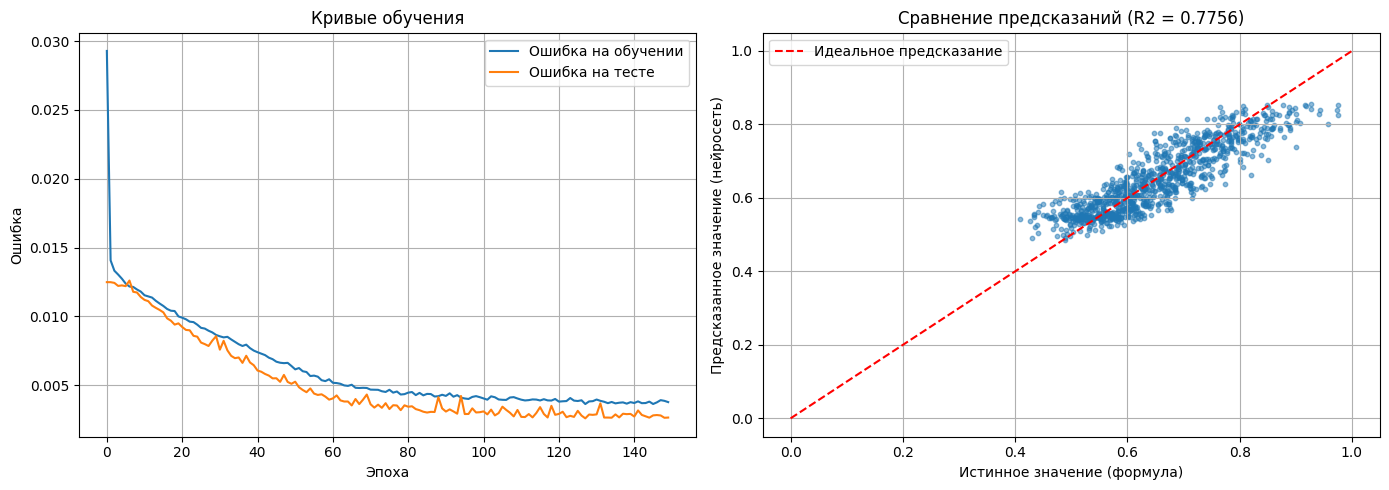


ПРИМЕРЫ ОЦЕНКИ ШРИФТОВ
Гармоничный шрифт (оценка): 1.000
Дисгармоничный шрифт (оценка): 0.370
It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://efc096665f7e1214b5.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://efc096665f7e1214b5.gradio.live

ВЫПОЛНЕНИЕ ЗАВЕРШЕНО


In [5]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torchinfo import summary
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from typing import Dict, Tuple, List, Any
import warnings
warnings.filterwarnings('ignore')

# Определяем устройство (GPU или CPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Используется устройство: {device}")


def harmony_function(g: float, h_target: float, sigma: float) -> float:
    """
    Вычисляет функцию гармонии для одного параметра.

    Формула: F = exp(-((g/h_target - 1)^2) / (2*sigma^2))

    Args:
        g: Текущее значение геометрического параметра
        h_target: Эталонное (целевое) значение параметра
        sigma: Допустимое отклонение (чем меньше, тем строже оценка)

    Returns:
        float: Значение гармонии от 0 до 1
    """
    if h_target <= 0:
        h_target = 0.01
    if sigma <= 0:
        sigma = 0.01
    deviation = (g / h_target) - 1
    return np.exp(-(deviation ** 2) / (2 * sigma ** 2))


def calculate_harmony_score(params: Dict[str, float], context: Dict[str, float]) -> float:
    """
    Вычисляет интегральную оценку гармоничности типографики.

    Формула: Q = sum(w_i * F_i)

    Args:
        params: Словарь с геометрическими параметрами:
            - font_type: тип шрифта (0=гротеск, 1=антиква)
            - contrast: контрастность (g1)
            - serif_width_ratio: относительная ширина засечки (g2)
            - relative_leading: относительный интерлиньяж (g3)
            - relative_line_length: относительная длина строки (g4)
            - proportion: пропорциональность буквы (g5)
            - weight: насыщенность (g6)
            - tracking: трекинг (g7)
        context: Словарь с контекстуальными параметрами:
            - media: носитель (1=печать, 2=экран, 3=мобильный)
            - lighting: освещение (0.2=темно, 0.5=низкое, 1.0=нормальное)
            - audience: аудитория (1.0=взрослые, 1.2=дети, 1.5=пожилые)

    Returns:
        float: Интегральная оценка гармоничности от 0 до 1
    """
    font_type = params.get('font_type', 0)

    # Целевые значения для контрастности (зависят от типа шрифта)
    if font_type == 0:
        h_contrast = 1.3  # для гротесков
    else:
        h_contrast = 3.0  # для антиквы

    lighting = context.get('lighting', 1.0)
    sigma_contrast = 0.2 * (0.5 + 0.5 * lighting)

    # Вычисляем функции гармонии для каждого параметра
    scores: Dict[str, float] = {}
    scores['contrast'] = harmony_function(params['contrast'], h_contrast, sigma_contrast)

    # Ширина засечки (только для антиквы)
    if font_type == 1:
        scores['serif_width'] = harmony_function(params.get('serif_width_ratio', 0.4), 0.4, 0.1)
    else:
        scores['serif_width'] = 1.0

    scores['leading'] = harmony_function(params['relative_leading'], 1.3, 0.1)
    scores['line_length'] = harmony_function(params['relative_line_length'], 15.0, 2.0)
    scores['proportion'] = harmony_function(params['proportion'], 1.0, 0.15)
    scores['weight'] = harmony_function(params['weight'], 400.0, 100.0)
    scores['tracking'] = np.exp(-(params['tracking'] ** 2) / (2 * 0.05 ** 2))

    # Весовые коэффициенты (зависят от носителя)
    if context['media'] == 1:  # печать
        weights = {
            'contrast': 0.15, 'serif_width': 0.05, 'leading': 0.25,
            'line_length': 0.20, 'proportion': 0.10, 'weight': 0.15, 'tracking': 0.10
        }
    elif context['media'] == 2:  # экран
        weights = {
            'contrast': 0.20, 'serif_width': 0.05, 'leading': 0.20,
            'line_length': 0.15, 'proportion': 0.10, 'weight': 0.20, 'tracking': 0.10
        }
    else:  # мобильный
        weights = {
            'contrast': 0.15, 'serif_width': 0.05, 'leading': 0.20,
            'line_length': 0.25, 'proportion': 0.10, 'weight': 0.15, 'tracking': 0.10
        }

    # Корректировка весов для детей и пожилых
    if context['audience'] > 1.2:
        weights['weight'] += 0.05
        weights['leading'] += 0.05
        weights['contrast'] -= 0.05
        weights['line_length'] -= 0.05

    # Итоговая оценка
    total_score = sum(weights[k] * scores[k] for k in weights)
    return total_score


def generate_dataset(n_samples: int = 5000) -> pd.DataFrame:
    """
    Генерирует синтетический датасет для обучения нейросети.

    Args:
        n_samples: Количество генерируемых образцов (по умолчанию 5000)

    Returns:
        pd.DataFrame: Датасет с 11 признаками и целевой переменной harmony_score
    """
    data: List[List[float]] = []

    for _ in range(n_samples):
        font_type = np.random.choice([0, 1])

        params = {
            'font_type': font_type,
            'contrast': np.random.uniform(1.0, 4.0),
            'serif_width_ratio': np.random.uniform(0.2, 0.8),
            'relative_leading': np.random.uniform(1.0, 1.8),
            'relative_line_length': np.random.uniform(10, 25),
            'proportion': np.random.uniform(0.7, 1.3),
            'weight': np.random.uniform(200, 800),
            'tracking': np.random.uniform(-0.1, 0.1)
        }

        context = {
            'media': np.random.choice([1, 2, 3]),
            'lighting': np.random.choice([0.2, 0.5, 1.0]),
            'audience': np.random.choice([1.0, 1.2, 1.5])
        }

        score = calculate_harmony_score(params, context)

        # Вектор признаков (нормализованный для нейросети)
        features = [
            params['contrast'],
            params['serif_width_ratio'],
            params['relative_leading'],
            params['relative_line_length'],
            params['proportion'],
            params['weight'] / 800.0,           # нормализация в [0.25, 1]
            params['tracking'] + 0.1,            # сдвиг в [0, 0.2]
            float(font_type),
            context['media'] / 3.0,              # нормализация в [0.33, 1]
            context['lighting'],
            context['audience'] / 1.5            # нормализация в [0.67, 1]
        ]

        data.append(features + [score])

    columns = [
        'contrast', 'serif_width', 'leading', 'line_length', 'proportion',
        'weight_norm', 'tracking_shift', 'font_type', 'media_norm',
        'lighting', 'audience_norm', 'harmony_score'
    ]

    return pd.DataFrame(data, columns=columns)


class HarmonyNN(nn.Module):
    """
    Нейросетевая модель для предсказания гармоничности типографики.

    Архитектура:
        - Входной слой: 11 признаков
        - Скрытые слои: 32 -> 16 -> 8 нейронов
        - Выходной слой: 1 нейрон с Sigmoid (оценка от 0 до 1)
    """

    def __init__(self, input_dim: int = 11) -> None:
        """
        Инициализация нейросети.

        Args:
            input_dim: Размерность входного вектора признаков (по умолчанию 11)
        """
        super(HarmonyNN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Linear(8, 1),
            nn.Sigmoid()
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Прямой проход нейросети.

        Args:
            x: Входной тензор признаков размерности (batch_size, 11)

        Returns:
            torch.Tensor: Предсказанные оценки гармоничности от 0 до 1
        """
        return self.net(x)


# =====================================================
# ОСНОВНОЙ БЛОК ЗАПУСКА
# =====================================================

def main() -> None:
    """Основная функция запуска прототипа."""

    print("Генерация датасета...")
    df = generate_dataset(5000)
    print(f"Датасет создан: {len(df)} образцов")

    # Подготовка данных
    feature_cols = [
        'contrast', 'serif_width', 'leading', 'line_length', 'proportion',
        'weight_norm', 'tracking_shift', 'font_type', 'media_norm',
        'lighting', 'audience_norm'
    ]
    X = df[feature_cols].values
    y = df['harmony_score'].values

    # Разделение на обучающую и тестовую выборки
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Конвертация в тензоры PyTorch
    X_train_tensor = torch.tensor(X_train, dtype=torch.float32).to(device)
    y_train_tensor = torch.tensor(y_train, dtype=torch.float32).reshape(-1, 1).to(device)
    X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
    y_test_tensor = torch.tensor(y_test, dtype=torch.float32).reshape(-1, 1).to(device)

    # Создание модели
    model = HarmonyNN(input_dim=11).to(device)

    # Вывод архитектуры нейросети
    print("\n" + "="*60)
    print("АРХИТЕКТУРА НЕЙРОСЕТИ (torchinfo)")
    print("="*60)
    summary(model, input_size=(1, 11))

    # Настройка обучения
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=32, shuffle=True)

    num_epochs = 150
    train_losses: List[float] = []
    test_losses: List[float] = []

    print("\n" + "="*60)
    print("ОБУЧЕНИЕ НЕЙРОСЕТИ")
    print("="*60)

    # Цикл обучения
    for epoch in range(num_epochs):
        model.train()
        epoch_loss = 0.0
        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()
            loss = criterion(model(batch_X), batch_y)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        train_losses.append(epoch_loss / len(train_loader))

        model.eval()
        with torch.no_grad():
            test_losses.append(criterion(model(X_test_tensor), y_test_tensor).item())

        if (epoch + 1) % 30 == 0:
            print(f"Эпоха {epoch+1}/{num_epochs} | Ошибка на обучении: {train_losses[-1]:.6f} | Ошибка на тесте: {test_losses[-1]:.6f}")

    # Оценка качества модели
    model.eval()
    with torch.no_grad():
        y_pred = model(X_test_tensor).cpu().numpy().flatten()
        y_test_cpu = y_test_tensor.cpu().numpy().flatten()

    mse = mean_squared_error(y_test_cpu, y_pred)
    r2 = r2_score(y_test_cpu, y_pred)

    print("\n" + "="*60)
    print("РЕЗУЛЬТАТЫ ТЕСТИРОВАНИЯ")
    print("="*60)
    print(f"Среднеквадратичная ошибка (MSE): {mse:.6f}")
    print(f"Коэффициент детерминации (R2): {r2:.4f}")
    print(f"Корень из MSE (RMSE): {np.sqrt(mse):.4f}")

    # Визуализация результатов
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(train_losses, label='Ошибка на обучении')
    axes[0].plot(test_losses, label='Ошибка на тесте')
    axes[0].set_xlabel('Эпоха')
    axes[0].set_ylabel('Ошибка')
    axes[0].set_title('Кривые обучения')
    axes[0].legend()
    axes[0].grid(True)

    axes[1].scatter(y_test_cpu, y_pred, alpha=0.5, s=10)
    axes[1].plot([0, 1], [0, 1], 'r--', label='Идеальное предсказание')
    axes[1].set_xlabel('Истинное значение (формула)')
    axes[1].set_ylabel('Предсказанное значение (нейросеть)')
    axes[1].set_title(f'Сравнение предсказаний (R2 = {r2:.4f})')
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.savefig('training_results.png', dpi=150)
    plt.show()

    # Примеры оценки шрифтов
    good_font = {
        'font_type': 0,
        'contrast': 1.3,
        'serif_width_ratio': 0.4,
        'relative_leading': 1.3,
        'relative_line_length': 15,
        'proportion': 1.0,
        'weight': 400,
        'tracking': 0.0
    }
    good_context = {'media': 1, 'lighting': 1.0, 'audience': 1.0}

    bad_font = {
        'font_type': 1,
        'contrast': 4.5,
        'serif_width_ratio': 0.8,
        'relative_leading': 1.0,
        'relative_line_length': 30,
        'proportion': 1.5,
        'weight': 800,
        'tracking': 0.1
    }
    bad_context = {'media': 2, 'lighting': 0.5, 'audience': 1.5}

    print("\n" + "="*60)
    print("ПРИМЕРЫ ОЦЕНКИ ШРИФТОВ")
    print("="*60)
    print(f"Гармоничный шрифт (оценка): {calculate_harmony_score(good_font, good_context):.3f}")
    print(f"Дисгармоничный шрифт (оценка): {calculate_harmony_score(bad_font, bad_context):.3f}")

    # Gradio интерфейс
    try:
        import gradio as gr

        model_for_prediction = HarmonyNN(input_dim=11).to('cpu')
        model_for_prediction.load_state_dict(model.state_dict())
        model_for_prediction.eval()

        def predict_harmony(contrast: float, serif_width: float, leading: float,
                           line_length: float, proportion: float, weight: float,
                           tracking: float, font_type: int, media: int,
                           lighting: float, audience: float) -> Tuple[float, float]:
            """
            Функция для Gradio интерфейса.

            Args:
                contrast, serif_width, leading, line_length, proportion, weight, tracking: Геометрические параметры
                font_type: Тип шрифта (0=гротеск, 1=антиква)
                media: Носитель (1=печать, 2=экран, 3=мобильный)
                lighting: Освещение (0.2-1.0)
                audience: Аудитория (1.0-1.5)

            Returns:
                Tuple[float, float]: Оценка по формуле и оценка нейросети
            """
            params = {
                'font_type': int(font_type),
                'contrast': float(contrast),
                'serif_width_ratio': float(serif_width),
                'relative_leading': float(leading),
                'relative_line_length': float(line_length),
                'proportion': float(proportion),
                'weight': float(weight),
                'tracking': float(tracking)
            }
            context = {
                'media': int(media),
                'lighting': float(lighting),
                'audience': float(audience)
            }

            score_formula = calculate_harmony_score(params, context)

            features = np.array([[
                float(contrast), float(serif_width), float(leading), float(line_length),
                float(proportion), float(weight)/800.0, float(tracking)+0.1,
                float(font_type), float(media)/3.0, float(lighting), float(audience)/1.5
            ]])
            features_tensor = torch.tensor(features, dtype=torch.float32)

            with torch.no_grad():
                score_nn = model_for_prediction(features_tensor).item()

            return round(score_formula, 4), round(score_nn, 4)

        with gr.Blocks(title="Typography Harmony") as demo:
            gr.Markdown("# Оценка гармоничности типографики")
            gr.Markdown("### Математическая модель + Нейросеть")

            with gr.Row():
                with gr.Column():
                    gr.Markdown("**Геометрические параметры**")
                    contrast = gr.Slider(1.0, 5.0, value=1.3, label="Контрастность")
                    serif_width = gr.Slider(0.2, 1.0, value=0.4, label="Относительная ширина засечки")
                    leading = gr.Slider(1.0, 2.0, value=1.3, label="Относительный интерлиньяж")
                    line_length = gr.Slider(10, 30, value=15, label="Относительная длина строки")
                    proportion = gr.Slider(0.7, 1.5, value=1.0, label="Пропорциональность")
                    weight = gr.Slider(200, 800, value=400, label="Насыщенность")
                    tracking = gr.Slider(-0.1, 0.1, value=0.0, label="Трекинг")

                with gr.Column():
                    gr.Markdown("**Контекстуальные параметры**")
                    font_type = gr.Radio(choices=[0, 1], value=0, label="Тип шрифта", info="0 = гротеск, 1 = антиква")
                    media = gr.Radio(choices=[1, 2, 3], value=1, label="Носитель", info="1 = печать, 2 = экран, 3 = мобильный")
                    lighting = gr.Slider(0.2, 1.0, value=1.0, label="Освещение")
                    audience = gr.Slider(1.0, 1.5, value=1.0, label="Аудитория")
                    btn = gr.Button("Оценить гармоничность", variant="primary")

            with gr.Row():
                score_formula = gr.Number(label="Оценка по математической формуле", precision=4)
                score_nn = gr.Number(label="Оценка нейросети", precision=4)

            gr.Markdown("""
            **Интерпретация оценки:**
            - от 0.8 до 1.0 : высокая гармоничность
            - от 0.5 до 0.8 : средняя гармоничность
            - от 0.0 до 0.5 : низкая гармоничность
            """)

            btn.click(fn=predict_harmony,
                      inputs=[contrast, serif_width, leading, line_length, proportion,
                              weight, tracking, font_type, media, lighting, audience],
                      outputs=[score_formula, score_nn])

        demo.launch(debug=True)

    except Exception as e:
        print(f"Gradio не запустился: {e}")

    print("\n" + "="*60)
    print("ВЫПОЛНЕНИЕ ЗАВЕРШЕНО")
    print("="*60)


# Запуск основной функции
if __name__ == "__main__":
    main()

In [6]:
from torchinfo import summary

# Создаём модель заново
class HarmonyNN(nn.Module):
    def __init__(self, input_dim=11):
        super(HarmonyNN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 32), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(32, 16), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(16, 8), nn.ReLU(),
            nn.Linear(8, 1), nn.Sigmoid()
        )
    def forward(self, x): return self.net(x)

model = HarmonyNN(11)

# Выводим архитектуру с явными параметрами
print("\n" + "="*60)
print("АРХИТЕКТУРА НЕЙРОСЕТИ")
print("="*60)
summary(model, input_size=(1, 11), col_names=["input_size", "output_size", "num_params", "trainable"], verbose=1)


АРХИТЕКТУРА НЕЙРОСЕТИ
Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Trainable
HarmonyNN                                [1, 11]                   [1, 1]                    --                        True
├─Sequential: 1-1                        [1, 11]                   [1, 1]                    --                        True
│    └─Linear: 2-1                       [1, 11]                   [1, 32]                   384                       True
│    └─ReLU: 2-2                         [1, 32]                   [1, 32]                   --                        --
│    └─Dropout: 2-3                      [1, 32]                   [1, 32]                   --                        --
│    └─Linear: 2-4                       [1, 32]                   [1, 16]                   528                       True
│    └─ReLU: 2-5                         [1, 16]                   [1, 16]                   --             

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Trainable
HarmonyNN                                [1, 11]                   [1, 1]                    --                        True
├─Sequential: 1-1                        [1, 11]                   [1, 1]                    --                        True
│    └─Linear: 2-1                       [1, 11]                   [1, 32]                   384                       True
│    └─ReLU: 2-2                         [1, 32]                   [1, 32]                   --                        --
│    └─Dropout: 2-3                      [1, 32]                   [1, 32]                   --                        --
│    └─Linear: 2-4                       [1, 32]                   [1, 16]                   528                       True
│    └─ReLU: 2-5                         [1, 16]                   [1, 16]                   --                        --
│    └─Dr